Draft

In [10]:

# data class Context
    # parameters
    # q(t) = 0vec
    # time # the init time the context is observed

# enum Part of Trajectory
    # ACCELERATION
    # CONSTANT
    # DECELERATION

# class TrapzoidTraject :
    # init (freq = 25 Hz)
    # setParameters(s_goal: vector, v_const: float, a: float)
    # getFullTrajectory() -> list of [A(t), partoftraject] until the end 
    # getTrajectoryAtTime(t) -> [A(t), partoftraject]

# class DatasetGenerator :
    # define context data min max range

    # generateDataset(n_contexts=1000, n_windows=50) -> list of [Context, Trajectory]
        # sampling combinations of Context and store in array        
        # for each context in n_contexts:
            # sampling window (init time of 50 points window) for n_windows times
            # generate full trajectory for the context
            # for each window:
                # store the context and the trajectory in the dataset



In [11]:
import numpy as np
import pandas as pd
from enum import Enum
from dataclasses import dataclass
from typing import List, Tuple
from tqdm import tqdm

class TrajectPart(Enum):
    ACCELERATION = 0
    CONSTANT = 1
    DECELERATION = 2

@dataclass
class Context:
    s_goal: float
    v_const: float
    a: float
    q_init: float = 0  # Current position at window start
    time_init: float = 0  # place holder
    part: TrajectPart = TrajectPart.CONSTANT  # place holder


In [ ]:

class TrapezoidTraject:
    def __init__(self, freq: int = 25):
        self.dt = 1.0 / freq
        
    def set_parameters(self, s_goal: float, v_const: float, a: float):
        self.s_goal = s_goal
        self.v_const = v_const
        self.a = a
        
        # Calculate phase durations
        self.t_acc = v_const / a
        self.s_acc = 0.5 * a * (self.t_acc**2)
        
        if 2 * self.s_acc > s_goal:
            # Short trajectory case: Triangle profile (never reaches v_const)
            self.v_peak = np.sqrt(s_goal * a)
            self.t_acc = self.v_peak / a
            self.t_const = 0
            self.t_total = 2 * self.t_acc
        else:
            # Standard Trapezoid
            self.s_const = s_goal - (2 * self.s_acc)
            self.t_const = self.s_const / v_const
            self.t_total = (2 * self.t_acc) + self.t_const

    def get_trajectory_at_time(self, t: float) -> Tuple[float, TrajectPart]:
        if t < self.t_acc:
            pos = 0.5 * self.a * (t**2)
            part = TrajectPart.ACCELERATION
        elif t < (self.t_acc + self.t_const):
            t_mid = t - self.t_acc
            pos = self.s_acc + (self.v_const * t_mid)
            part = TrajectPart.CONSTANT
        elif t <= self.t_total:
            t_dec = t - self.t_acc - self.t_const
            # v_end = v_const - a*t_dec
            pos = (self.s_goal - self.s_acc) + (self.v_const * t_dec - 0.5 * self.a * (t_dec**2))
            part = TrajectPart.DECELERATION
        else:
            pos, part = self.s_goal, TrajectPart.DECELERATION
        return pos, part

class DatasetGenerator:
    def __init__(self):
        # Range definitions from your notes
        self.range_s = [1.0, 5.0] # m
        self.range_v = [0.1, 0.2] # m/s
        self.range_a = [0.02, 0.04] # m/s^2

        self.sample_contexts: List[Context] = []
        self.dataset = None # will hold the final DataFrame

    def generate_dataset(self, n_contexts=2000, n_windows=50, window_size=50):
        data_rows = []
        traject_gen = TrapezoidTraject(freq=25)

        # Sample Context Parameters first
        sample_contexts: List[Context] = []
        for _ in tqdm(range(n_contexts), desc="Generating Contexts"):
            s_g = np.random.uniform(*self.range_s)
            v_c = np.random.uniform(*self.range_v)
            acc = np.random.uniform(*self.range_a)
            ctx = Context(s_g, v_c, acc, q_init=0.0, time_init=0.0, part=TrajectPart.ACCELERATION) # q_init and time_init will be updated later
            sample_contexts.append(ctx)
        self.sample_contexts = sample_contexts
        
        # For each commanded context, generate trajectory samples
        for context in tqdm(sample_contexts, desc="Generating Trajectories"):
            traject_gen.set_parameters(context.s_goal, context.v_const, context.a)
            total_time = traject_gen.t_total
            
            # Sample random window start times
            # Ensure window fits within the trajectory duration
            max_start_t = max(0, total_time - (window_size * traject_gen.dt))
            start_times = np.random.uniform(0, max_start_t, n_windows)

            for t_start in start_times:
                # 1. Capture the Context at t_start
                q_init, part_init = traject_gen.get_trajectory_at_time(t_start)
                ctx = Context(context.s_goal, context.v_const, context.a, q_init, t_start, part_init)

                # 2. Capture the 50-step trajectory segment
                trajectory_segment = []
                for step in range(window_size):
                    t_current = t_start + (step * traject_gen.dt)
                    pos, _ = traject_gen.get_trajectory_at_time(t_current)
                    trajectory_segment.append(pos)

                # Flatten for CSV: Context features + 50 trajectory points
                row = [ctx.s_goal, ctx.v_const, ctx.a, ctx.q_init, ctx.time_init, ctx.part.value]
                row.extend(trajectory_segment)
                data_rows.append(row)

        # Create Header
        columns = ['s_goal', 'v_const', 'accel', 'q_init', 't_init', 'part_enum']
        columns += [f'pos_{i}' for i in range(window_size)]
        self.dataset = pd.DataFrame(data_rows, columns=columns).astype('float32')

        return self.dataset



Generating Trajectories: 100%|██████████| 20000/20000 [00:28<00:00, 704.26it/s]


Dataset saved with shape: (1000000, 56)


In [ ]:

# Execution
dataGenerator = DatasetGenerator()
df = dataGenerator.generate_dataset(n_contexts=20000, n_windows=50) # Reduced for example
df.to_csv("trajectory_dataset.csv", index=False)
print(f"Dataset saved with shape: {df.shape}")    


## Viewing and Visualize

In [13]:
# view the first few rows of the dataset
print(df.head())

    s_goal  v_const     accel    q_init     t_init  part_enum     pos_0  \
0  4.79684  0.12998  0.026831  2.716781  23.323738        1.0  2.716781   
1  4.79684  0.12998  0.026831  3.446396  28.937017        1.0  3.446396   
2  4.79684  0.12998  0.026831  2.901183  24.742432        1.0  2.901183   
3  4.79684  0.12998  0.026831  2.717655  23.330463        1.0  2.717655   
4  4.79684  0.12998  0.026831  4.681250  38.813519        2.0  4.681250   

      pos_1     pos_2     pos_3  ...    pos_40    pos_41    pos_42    pos_43  \
0  2.721980  2.727179  2.732378  ...  2.924749  2.929948  2.935148  2.940347   
1  3.451595  3.456794  3.461993  ...  3.654364  3.659563  3.664762  3.669961   
2  2.906382  2.911582  2.916781  ...  3.109151  3.114350  3.119550  3.124749   
3  2.722854  2.728054  2.733253  ...  2.925623  2.930823  2.936022  2.941221   
4  4.684379  4.687465  4.690507  ...  4.772919  4.774330  4.775699  4.777025   

     pos_44    pos_45    pos_46    pos_47    pos_48    pos_49  
0  2

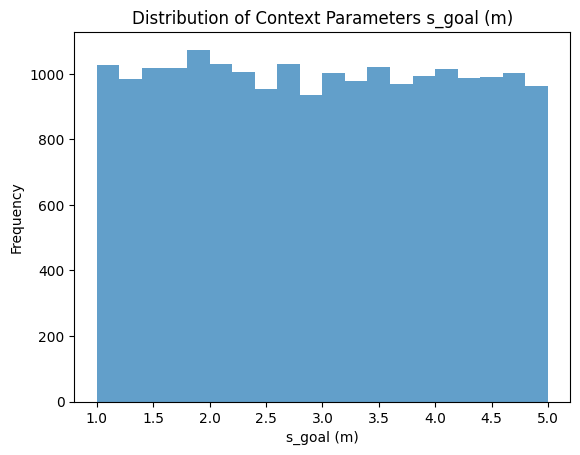

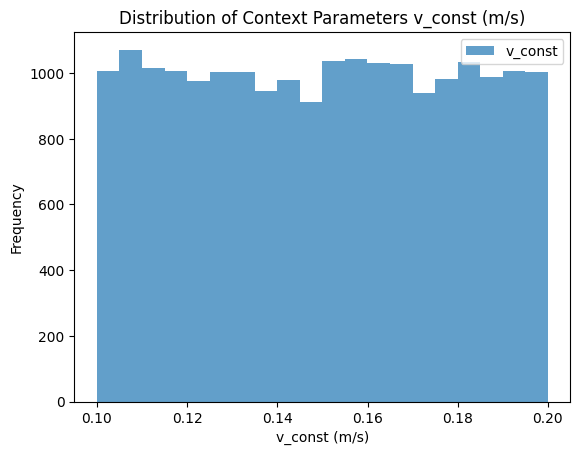

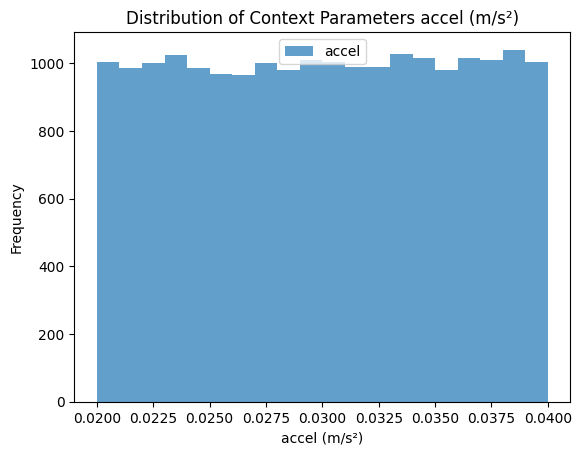

In [17]:
# plot histogram for s_goal, v_const, and accel in dataGenerator.sample_contexts to visualize

import matplotlib.pyplot as plt
s_goals = [ctx.s_goal for ctx in dataGenerator.sample_contexts]
plt.hist(s_goals, bins=20, alpha=0.7, label='s_goal')
plt.title("Distribution of Context Parameters s_goal (m)")
plt.xlabel("s_goal (m)")
plt.ylabel("Frequency")
plt.show()

v_consts = [ctx.v_const for ctx in dataGenerator.sample_contexts]
plt.hist(v_consts, bins=20, alpha=0.7, label='v_const')
plt.legend()
plt.title("Distribution of Context Parameters v_const (m/s)")
plt.xlabel("v_const (m/s)")
plt.ylabel("Frequency")
plt.show()

accels = [ctx.a for ctx in dataGenerator.sample_contexts]
plt.hist(accels, bins=20, alpha=0.7, label='accel')
plt.legend()
plt.title("Distribution of Context Parameters accel (m/s²)")
plt.xlabel("accel (m/s²)")
plt.ylabel("Frequency")
plt.show()


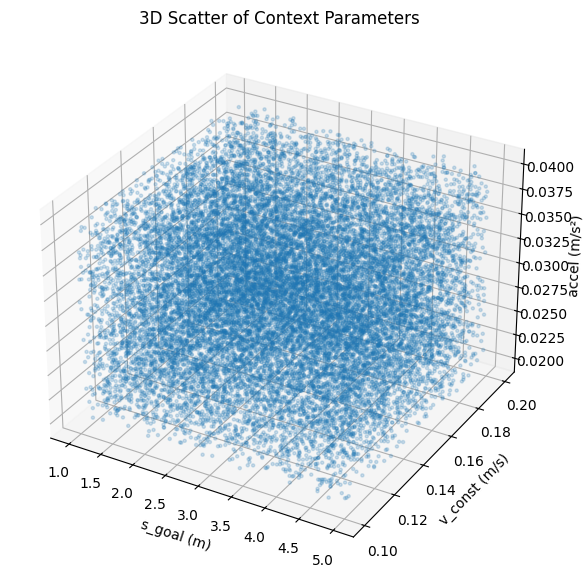

In [23]:
# for each context, plot the s_goal, v_const, and accel distributions in 3 axis scatter plot
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
s_goals = [ctx.s_goal for ctx in dataGenerator.sample_contexts]
v_consts = [ctx.v_const for ctx in dataGenerator.sample_contexts]
accels = [ctx.a for ctx in dataGenerator.sample_contexts]
ax.scatter(s_goals, v_consts, accels, alpha=0.2, marker='.')
ax.set_xlabel('s_goal (m)')
ax.set_ylabel('v_const (m/s)')
ax.set_zlabel('accel (m/s²)')
plt.title("3D Scatter of Context Parameters")
plt.show()

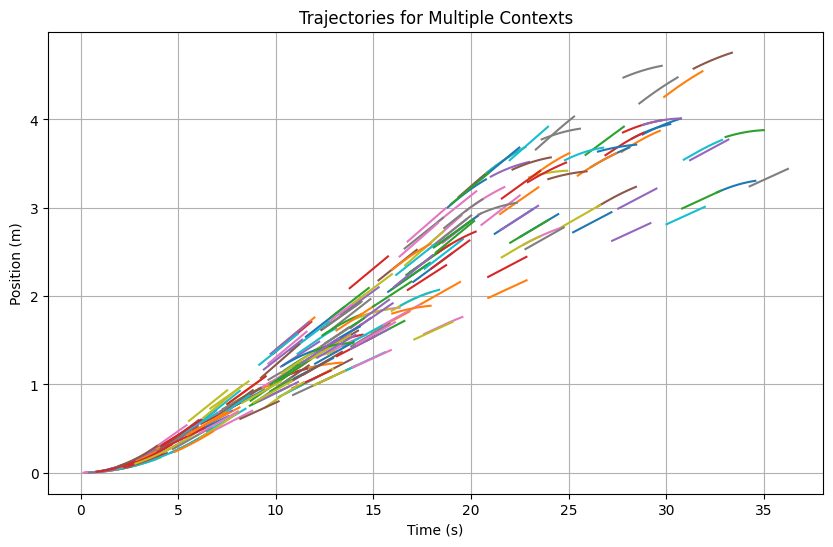

In [15]:
# plot 3 trajectories per context for 20 random contexts to visualize, in the same plot all
random_contexts = np.random.choice(dataGenerator.sample_contexts, 50, replace=False)
plt.figure(figsize=(10, 6))
for ctx in random_contexts:
    traject_gen = TrapezoidTraject(freq=25)
    traject_gen.set_parameters(ctx.s_goal, ctx.v_const, ctx.a)
    total_time = traject_gen.t_total

    for _ in range(5):  # Plot 3 trajectories per context
        start_t = np.random.uniform(0, max(0, total_time - (50 * traject_gen.dt)))
        times = [start_t + i * traject_gen.dt for i in range(50)]
        positions = [traject_gen.get_trajectory_at_time(t)[0] for t in times]
        plt.plot(times, positions)

plt.xlabel("Time (s)")
plt.ylabel("Position (m)")
plt.title("Trajectories for Multiple Contexts")
plt.grid()
plt.show()
